# MNIST Handwritten Digit Classification

A convolutional neural network (CNN) built with TensorFlow/Keras to classify handwritten digits from the MNIST dataset.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


## 2. Load the MNIST Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing data:", X_test.shape)
print("Testing labels:", y_test.shape)


Training data: (60000, 28, 28)
Training labels: (60000,)
Testing data: (10000, 28, 28)
Testing labels: (10000,)


## 3. Data Preprocessing

In [3]:
# Normalize pixel values to the range 0–1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add the channel dimension required by the CNN
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


## 4. Visualize Sample Images

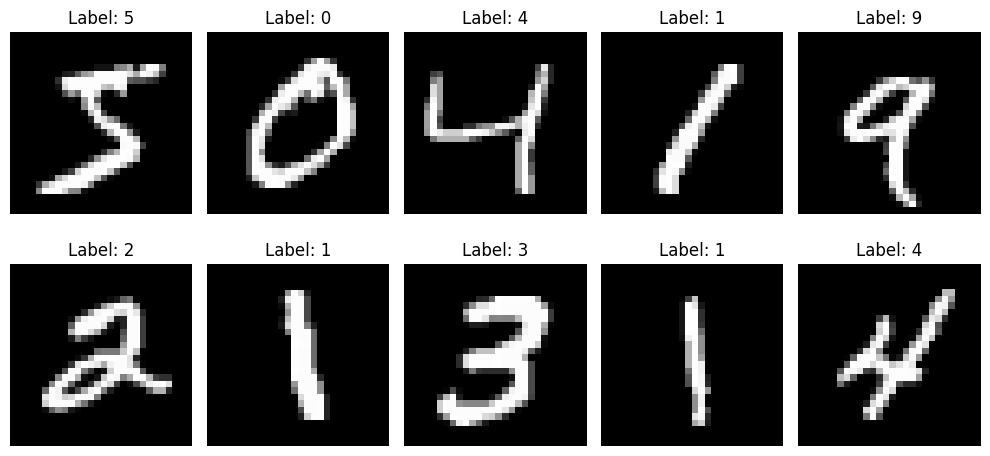

In [4]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 5. Build the CNN Model

In [5]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Compile the Model

In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


## 7. Train the Model

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.9173 - loss: 0.2705 - val_accuracy: 0.9822 - val_loss: 0.0594
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.9766 - loss: 0.0765 - val_accuracy: 0.9870 - val_loss: 0.0444
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - accuracy: 0.9831 - loss: 0.0547 - val_accuracy: 0.9892 - val_loss: 0.0368
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.9875 - loss: 0.0407 - val_accuracy: 0.9903 - val_loss: 0.0353
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.9892 - loss: 0.0338 - val_accuracy: 0.9908 - val_loss: 0.0374
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9906 - loss: 0.0306 - val_accuracy: 0.9915 - val_loss: 0.0308
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.9921 - loss: 0.0244 - val_accuracy: 0.9910 - val_loss: 0.0324
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 54ms/step - accuracy: 0.9935 - loss: 0.0205 - 

## 8. Evaluate the Model

In [8]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Test Loss: 0.0307
Test Accuracy: 99.00%


## 9. Training and Validation Accuracy

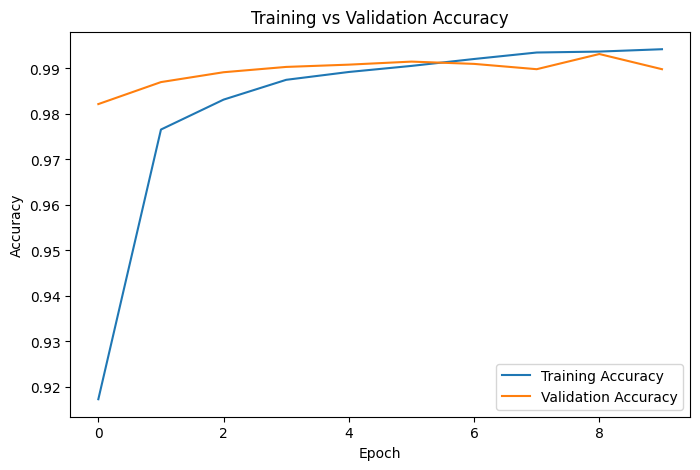

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


## 10. Training and Validation Loss

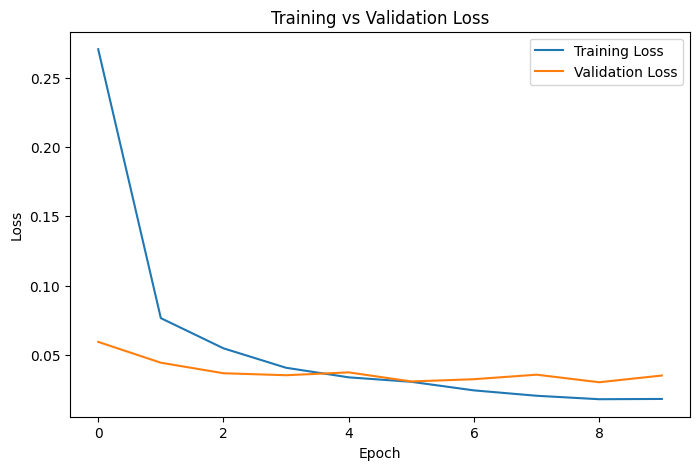

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


## 11. Confusion Matrix

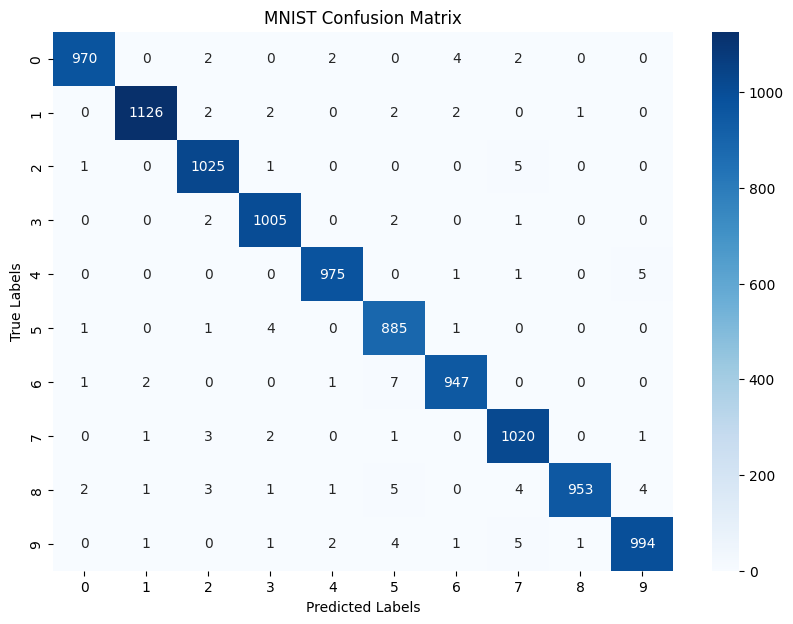

In [11]:
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

conf_mat = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues")
plt.ylabel("True Labels")
plt.xlabel("Predicted Labels")
plt.title("MNIST Confusion Matrix")
plt.show()


## 12. Test a Sample Prediction

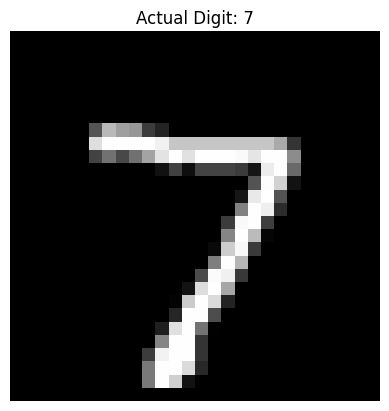

Predicted digit: 7
Confidence: 100.00%


In [12]:
index = 0

plt.imshow(X_test[index].squeeze(), cmap="gray")
plt.title(f"Actual Digit: {y_test[index]}")
plt.axis("off")
plt.show()

prediction = model.predict(X_test[index:index + 1], verbose=0)
predicted_digit = np.argmax(prediction[0])
confidence = np.max(prediction[0]) * 100

print("Predicted digit:", predicted_digit)
print(f"Confidence: {confidence:.2f}%")


## 13. Save the Trained Model

In [13]:
model.save("mnist_cnn.keras")
print("Model saved as mnist_cnn.keras")


Model saved as mnist_cnn.keras


## 14. Predict a Digit from an External Image

The image is converted to grayscale, resized to 28×28 pixels, normalized, and reshaped to the CNN input format `(1, 28, 28, 1)`.

Path of the image to be predicted:  MNIST_digit (1).png


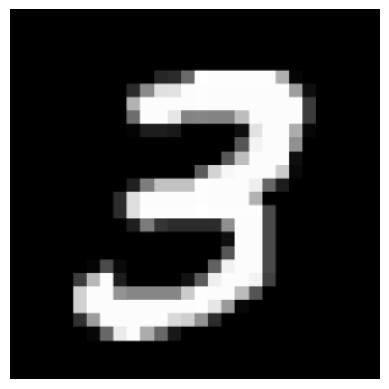

Final input shape: (1, 28, 28, 1)
The handwritten digit is recognized as: 3
Confidence: 100.00%


In [15]:
input_image_path = input("Path of the image to be predicted: ")

input_image = cv2.imread(input_image_path)

if input_image is None:
    raise FileNotFoundError("Could not load the image. Check the file path.")

# Display the original image
plt.imshow(cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Convert to grayscale
grayscale = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)

# Resize to MNIST dimensions
input_image_resize = cv2.resize(grayscale, (28, 28))

# Normalize pixel values
image_normalized = input_image_resize.astype("float32") / 255.0

# Reshape for CNN: (batch, height, width, channel)
image_reshaped = image_normalized.reshape(1, 28, 28, 1)

print("Final input shape:", image_reshaped.shape)

# Predict
input_prediction = model.predict(image_reshaped, verbose=0)

predicted_digit = np.argmax(input_prediction[0])
confidence = np.max(input_prediction[0]) * 100

print("The handwritten digit is recognized as:", predicted_digit)
print(f"Confidence: {confidence:.2f}%")
